In [3]:
import numpy as np
# import matplotlib.pyplot as plt
import pandas as pd


In [6]:
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### Observation

- The dataset contains both numerical and categorical features.
- Categorical columns:
    - Geography
    - Gender
    - Surname
- Remaining columns are numerical.
- No obvious datatype issues are observed at this stage.

#  Missing Values

Checking whether the dataset contains any missing values.

In [13]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Observation

- No missing values are present in the dataset.
- No imputation is required.

#  Duplicate Records

Checking duplicate rows in the dataset.

In [14]:
df.duplicated().sum()

np.int64(0)

### Observation

- No duplicate rows were found in the dataset.

#  Target Variable Analysis

Understanding the target column.

In [15]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [16]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [17]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


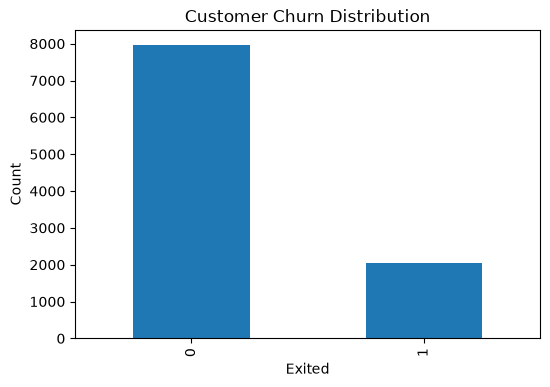

In [18]:
import matplotlib.pyplot as plt

df["Exited"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

### Observation

- 0 indicates customers who stayed.
- 1 indicates customers who exited.
- The dataset appears to be imbalanced.
- Most customers did not churn.

#  Feature Classification

Separating numerical and categorical features.

In [20]:

categorical_features = df.select_dtypes(include = 'object').columns.tolist()
categorical_features

C:\Users\DUBAI LAPTOP BAZAR\AppData\Local\Temp\ipykernel_21460\2726903846.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include = 'object').columns.tolist()


['Surname', 'Geography', 'Gender']

In [21]:
numerical_features = df.select_dtypes(exclude="object").columns.tolist()

numerical_features

['RowNumber',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [22]:
print("Categorical Features :", len(categorical_features))
print("Numerical Features   :", len(numerical_features))

Categorical Features : 3
Numerical Features   : 11


### Observation

Categorical Features:

- Geography
- Gender
- Surname

Numerical Features include:

- CreditScore
- Age
- Balance
- EstimatedSalary
- Tenure
- NumOfProducts
- HasCrCard
- IsActiveMember
- Exited

#  Initial Observations

## Key Findings

1. Dataset contains 10,000 customer records.

2. No missing values were found.

3. No duplicate rows were found.

4. The dataset contains both numerical and categorical features.

5. The target variable is "Exited".

6. The dataset is slightly imbalanced.

7. Some columns (RowNumber, CustomerId, Surname) may not contribute to prediction and will be evaluated during preprocessing.

# Sprint Summary

## Tasks Completed

- Dataset loaded successfully
- Dataset overview completed
- Dataset information checked
- Data types identified
- Missing values checked
- Duplicate values checked
- Target variable explored
- Feature types identified
- Initial observations documented



In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [24]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64